# ZOMATO RESTAURANT SUCCESS FACTORS ANALYSIS

### Business Objective

The primary objective of this project is to analyze restaurant data from Zomato to identify the factors that contribute to restaurant success and customer satisfaction. By examining attributes such as location, cuisine type, pricing, online delivery availability, table booking services, and customer ratings, this analysis aims to uncover actionable insights that can support strategic business decisions.

The project seeks to answer key business questions such as:

* What factors have the greatest influence on restaurant ratings?
* Which cuisines are most preferred by customers?
* How do pricing and service offerings impact customer satisfaction?
* Which cities or locations show the highest restaurant performance?
* What characteristics are commonly associated with highly rated restaurants?

The insights generated from this analysis can help restaurant owners optimize their operations, improve customer experience, and increase competitiveness in the market.

---

# Introduction

The restaurant industry is highly competitive, making it essential for businesses to understand the factors that influence customer satisfaction and overall restaurant performance. Online food discovery platforms such as the mobile_app reference is not appropriate here, so plain "Zomato" is fine as a brand mention. Zomato provides extensive information about restaurants, including ratings, cuisines, pricing, location, and service features, creating valuable opportunities for data-driven analysis.

This project performs an Exploratory Data Analysis (EDA) of the Zomato restaurant dataset to investigate the relationships between restaurant characteristics and customer ratings. The analysis explores key variables such as cuisine types, average cost for two, price range, online delivery services, table booking availability, and geographical distribution.

Through statistical analysis and data visualization techniques, the project aims to identify trends, customer preferences, and performance patterns among restaurants. The findings provide meaningful business insights that can support restaurant owners in improving service quality, enhancing customer satisfaction, and making informed operational decisions. Additionally, the analysis helps consumers better understand restaurant options based on ratings, affordability, and available amenities.

--

## Key Business Questions

1. What factors contribute most to higher restaurant ratings?
2. Which cuisines are most preferred by customers?
3. Does online delivery impact customer satisfaction?
4. Does table booking improve restaurant ratings?
5. How does pricing affect customer ratings?
6. Which cities have the best-performing restaurants?
7. What characteristics are common among successful restaurants?
8. What recommendations can improve restaurant performance?

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv("Indian-Resturants.csv")

# Data Overview:

In [3]:
# Display the first 5 rows
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [4]:
# Shape of dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (211944, 26)


**The dataset contains 211,944 restaurants and 26 features, providing extensive information about restaurant operations, ratings, cuisines, and services.**

In [5]:
# Column names
print(df.columns)

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')


In [6]:
# datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

**Data types were reviewed to ensure variables were stored in the appropriate format for analysis and visualization.**

# Data Cleaning and Preprocessing

In [7]:
# Check Missing Values
df.isnull().sum()

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

In [8]:
# Handle Missing Values
# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [9]:
# Verify Missing Values Again
df.isnull().sum()

res_id                  0
name                    0
establishment           0
url                     0
address                 0
city                    0
city_id                 0
locality                0
latitude                0
longitude               0
zipcode                 0
country_id              0
locality_verbose        0
cuisines                0
timings                 0
average_cost_for_two    0
price_range             0
currency                0
highlights              0
aggregate_rating        0
rating_text             0
votes                   0
photo_count             0
opentable_support       0
delivery                0
takeaway                0
dtype: int64

**After preprocessing, the dataset was verified to ensure no remaining missing values that could affect the analysis**

In [10]:
#Check Duplicate Records
duplicates = df.duplicated().sum()

print(
    f"Duplicate Records: {duplicates}"
)

Duplicate Records: 151533


**Duplicate records were checked to prevent repeated observations from biasing the results.**

In [11]:
# Remove Duplicate Records
df.drop_duplicates(
    inplace=True
)

In [12]:
# Verify Duplicate Removal
print(
    f"Duplicates Remaining: {df.duplicated().sum()}"
)

Duplicates Remaining: 0


**Duplicate records were successfully removed, ensuring each observation represents a unique restaurant entry.**

In [13]:
# Convert Incorrect Data Types
df['average_cost_for_two'] = pd.to_numeric(
    df['average_cost_for_two'],
    errors='coerce'
)

df['votes'] = pd.to_numeric(
    df['votes'],
    errors='coerce'
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60411 entries, 0 to 211942
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   res_id                60411 non-null  int64  
 1   name                  60411 non-null  object 
 2   establishment         60411 non-null  object 
 3   url                   60411 non-null  object 
 4   address               60411 non-null  object 
 5   city                  60411 non-null  object 
 6   city_id               60411 non-null  int64  
 7   locality              60411 non-null  object 
 8   latitude              60411 non-null  float64
 9   longitude             60411 non-null  float64
 10  zipcode               60411 non-null  object 
 11  country_id            60411 non-null  int64  
 12  locality_verbose      60411 non-null  object 
 13  cuisines              60411 non-null  object 
 14  timings               60411 non-null  object 
 15  average_cost_for_two  6

**Data types were validated after conversion to ensure consistency and compatibility with statistical analysis.**

In [15]:
# Clean Column Names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [16]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

**Column names were standardized by removing unnecessary spaces and converting them to lowercase for improved readability and easier coding.**

# Descriptive Statistics

In [17]:
df.describe()

,res_id,city_id,latitude,longitude,country_id,average_cost_for_two,price_range,aggregate_rating,votes,photo_count,opentable_support,delivery,takeaway
count,6.041100e+04,60411.000000,60411.000000,60411.000000,60411.0,60411.00000,60411.000000,60411.000000,60411.000000,60411.000000,60411.0,60411.000000,60411.0
mean,1.309279e+07,3417.519376,21.349912,76.587636,1.0,538.31246,1.730844,3.032863,261.587062,194.262303,0.0,-0.371737,-1.0
std,8.133021e+06,5179.013230,41.190015,10.600963,0.0,593.86415,0.880470,1.440739,728.316928,705.715642,0.0,0.925274,0.0
min,5.000000e+01,1.000000,0.000000,0.000000,1.0,0.00000,1.000000,0.000000,-18.000000,0.000000,0.0,-1.000000,-1.0
25%,3.000479e+06,7.000000,16.323783,74.653081,1.0,200.00000,1.000000,2.900000,7.000000,1.000000,0.0,-1.000000,-1.0
50%,1.869150e+07,26.000000,22.320915,77.134838,1.0,400.00000,1.000000,3.500000,42.000000,11.000000,0.0,-1.000000,-1.0
75%,1.886668e+07,11295.000000,26.744393,79.928133,1.0,600.00000,2.000000,4.000000,207.000000,82.000000,0.0,1.000000,-1.0
max,1.915979e+07,11354.000000,10000.000000,91.832769,1.0,30000.00000,4.000000,4.900000,42539.000000,17702.000000,0.0,1.000000,-1.0


**Descriptive statistics provide an overview of restaurant ratings,
pricing, and customer engagement levels.**

**Understanding the distribution of these variables helps identify
general market trends.**

# Exploratory Data Analysis

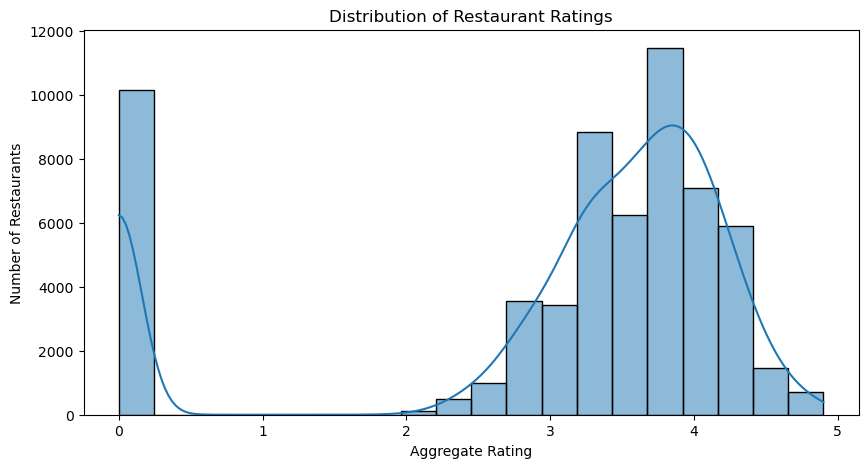

In [18]:
# Distribution of Restaurant Rating
plt.figure(figsize=(10,5))

sns.histplot(
    df['aggregate_rating'],
    bins=20,
    kde=True
)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')

plt.show()



**The distribution of ratings helps understand how customer satisfaction is spread across restaurants and identifies whether most restaurants receive low, average, or high ratings.**

## Location Analysis


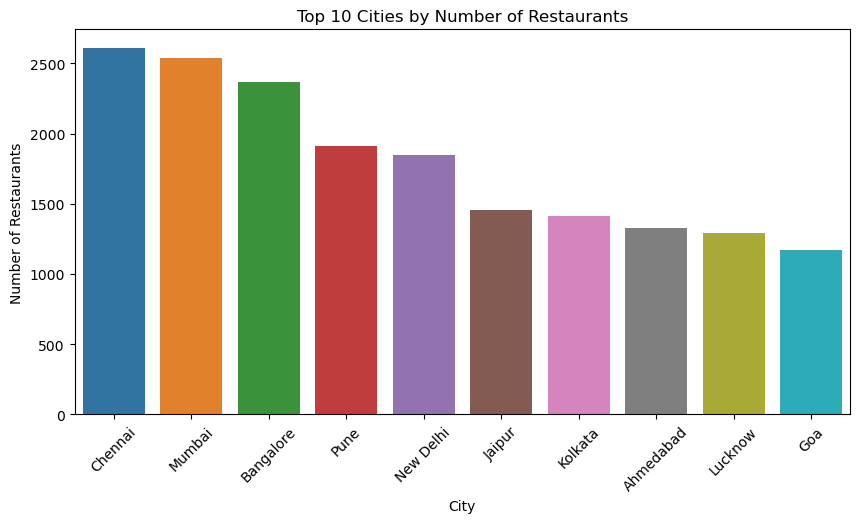

In [19]:
# Restaurant Distribution by City
city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=city_counts.index,
    y=city_counts.values
)

plt.title('Top 10 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)

plt.show()

**Cities with a high concentration of restaurants indicate strong market demand and business opportunities. However, they may also experience higher competition, requiring restaurants to differentiate through service quality, pricing, and customer experience.**

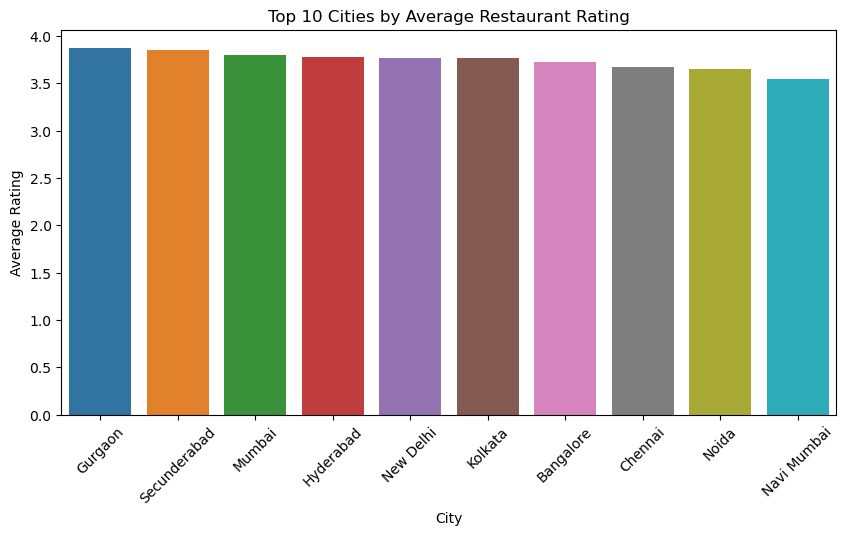

In [20]:
# Ratings Across Cities
city_ratings = (
    df.groupby('city')['aggregate_rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_ratings.index,
    y=city_ratings.values
)

plt.title('Top 10 Cities by Average Restaurant Rating')
plt.xlabel('City')
plt.ylabel('Average Rating')

plt.xticks(rotation=45)

plt.show()

**Cities with higher average ratings may reflect superior service quality, stronger restaurant competition, or greater alignment with customer preferences. Understanding these regional differences can help restaurant owners benchmark performance and identify potential growth opportunities.**

## Cuisine Analysis (Customer Preference Analysis)

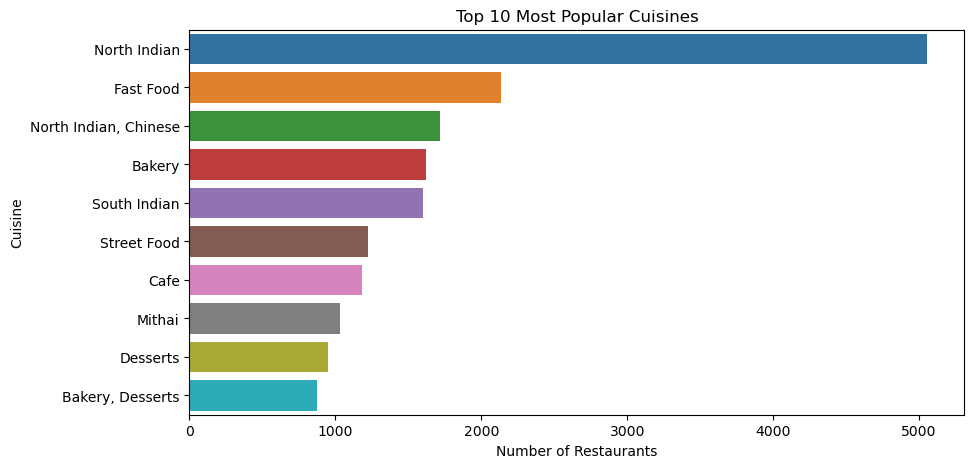

In [21]:
# Most Popular Cuisines
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')

plt.show()

**The strong presence of North Indian cuisine across restaurants suggests sustained customer demand and market acceptance, making it a strategically important cuisine category for restaurant operators seeking broader customer reach.**

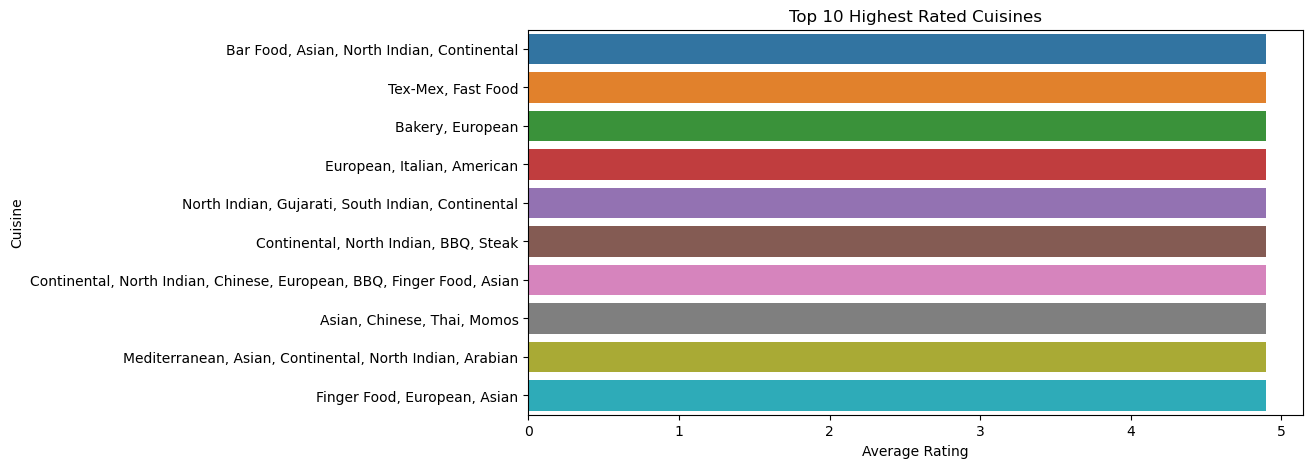

In [22]:
# Highest Rated Cuisines
top_rated = (
    df.groupby('cuisines')['aggregate_rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_rated.values,
    y=top_rated.index
)

plt.title('Top 10 Highest Rated Cuisines')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

plt.show()

**Cuisine categories with the highest average ratings demonstrate stronger customer satisfaction and perceived value. These categories may offer insights into evolving consumer tastes and can help restaurant operators identify profitable market opportunities.**

## Pricing Analysis

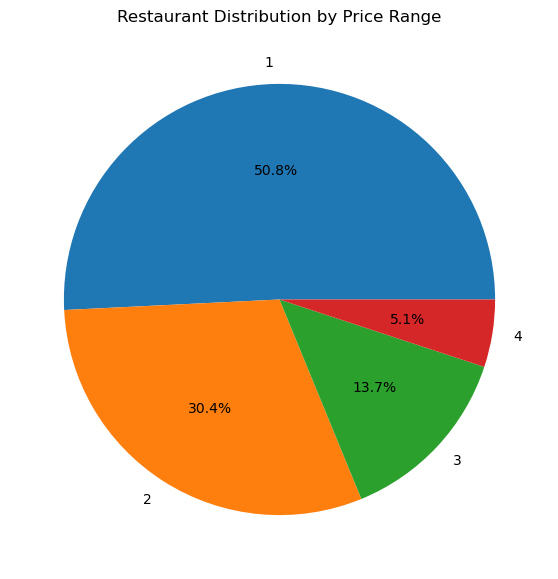

In [23]:
#Price Range Distribution
price_counts = df['price_range'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    price_counts,
    labels=price_counts.index,
    autopct='%1.1f%%'
)

plt.title('Restaurant Distribution by Price Range')

plt.show()

**The distribution highlights the proportion of restaurants operating across different pricing segments, providing insight into market affordability and customer accessibility.**

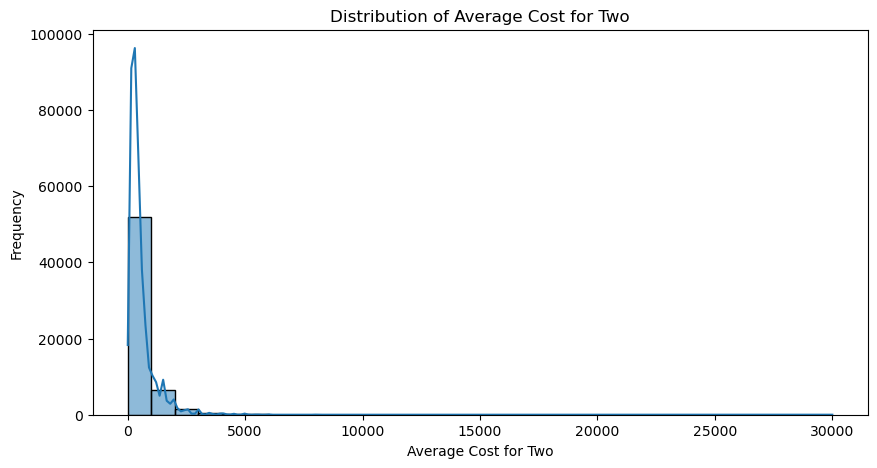

In [24]:
# Average Cost for Two
plt.figure(figsize=(10,5))

sns.histplot(
    df['average_cost_for_two'],
    bins=30,
    kde=True
)

plt.title('Distribution of Average Cost for Two')
plt.xlabel('Average Cost for Two')
plt.ylabel('Frequency')

plt.show()

**The cost distribution reveals the dominant spending range among restaurants, helping identify the primary target customer segment within the market.**

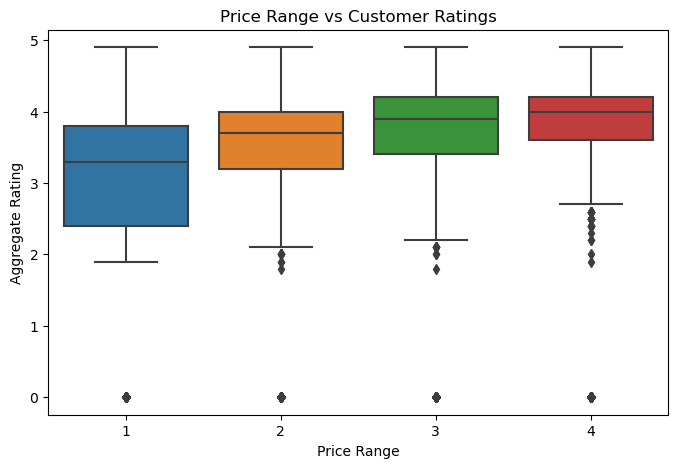

In [25]:
# Price Range vs Rating
plt.figure(figsize=(8,5))

sns.boxplot(
    x='price_range',
    y='aggregate_rating',
    data=df
)

plt.title('Price Range vs Customer Ratings')
plt.xlabel('Price Range')
plt.ylabel('Aggregate Rating')

plt.show()

**The box plot evaluates whether premium-priced restaurants consistently achieve higher customer satisfaction levels and highlights rating variability across pricing segments.**

## Restaurant Success Factors Analysis

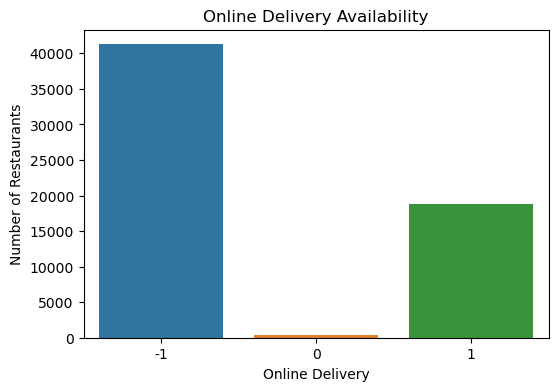

In [26]:
# Online Delivery Availability
plt.figure(figsize=(6,4))

sns.countplot(
    x='delivery',
    data=df
)

plt.title('Online Delivery Availability')
plt.xlabel('Online Delivery')
plt.ylabel('Number of Restaurants')

plt.show()

**Online delivery has become an important competitive feature in the restaurant industry. Understanding its adoption rate helps evaluate how restaurants are adapting to evolving customer preferences.**

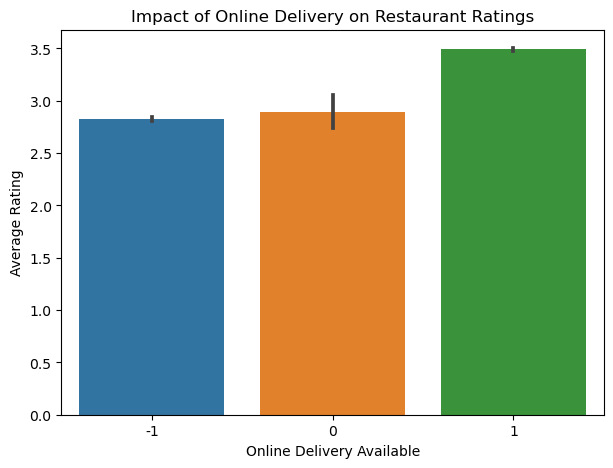

In [27]:
# Impact of Online Delivery on Restaurant Ratings
plt.figure(figsize=(7,5))

sns.barplot(
    x='delivery',
    y='aggregate_rating',
    data=df
)

plt.title('Impact of Online Delivery on Restaurant Ratings')
plt.xlabel('Online Delivery Available')
plt.ylabel('Average Rating')

plt.show()

**Restaurants offering online delivery tend to provide greater convenience to customers, which may positively influence customer satisfaction and overall ratings.**

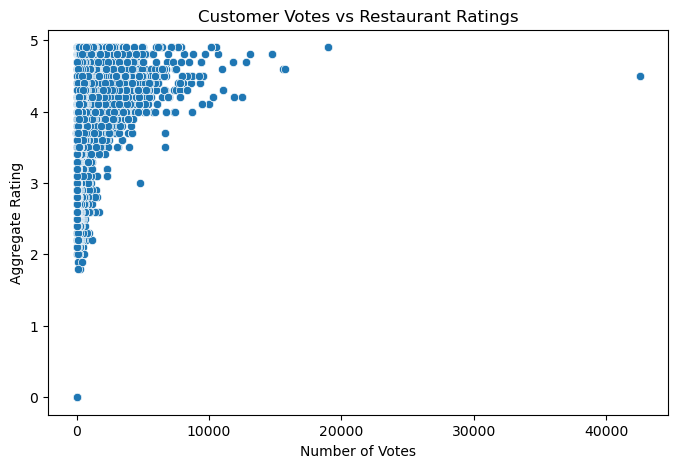

In [28]:
# Customer Engagement: Votes vs Ratings
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='votes',
    y='aggregate_rating'
)

plt.title('Customer Votes vs Restaurant Ratings')
plt.xlabel('Number of Votes')
plt.ylabel('Aggregate Rating')

plt.show()

**Restaurants with higher customer engagement often maintain stronger ratings, suggesting that popularity and customer trust may contribute to overall restaurant success.**

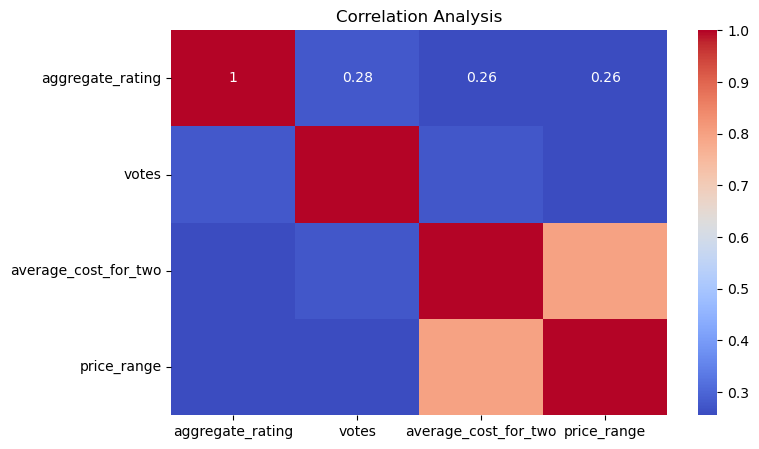

In [29]:
# Correlation Analysis of Success Factors
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['aggregate_rating',
        'votes',
        'average_cost_for_two',
        'price_range']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Analysis')
plt.show()

**Correlation analysis helps identify which operational and customer-related factors exhibit the strongest relationship with restaurant ratings.**

# Restaurant Segmentation

## Objective:

**Restaurant segmentation helps group restaurants with similar characteristics, enabling a better understanding of different market segments and business strategies.**

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[
    ['aggregate_rating',
     'votes',
     'average_cost_for_two']
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

df[['aggregate_rating',
    'votes',
    'average_cost_for_two',
    'Cluster']].head()

,aggregate_rating,votes,average_cost_for_two,Cluster
0,4.4,814,700,0
1,4.4,1203,600,0
2,4.2,801,300,0
3,4.3,693,300,0
4,4.9,470,1000,0


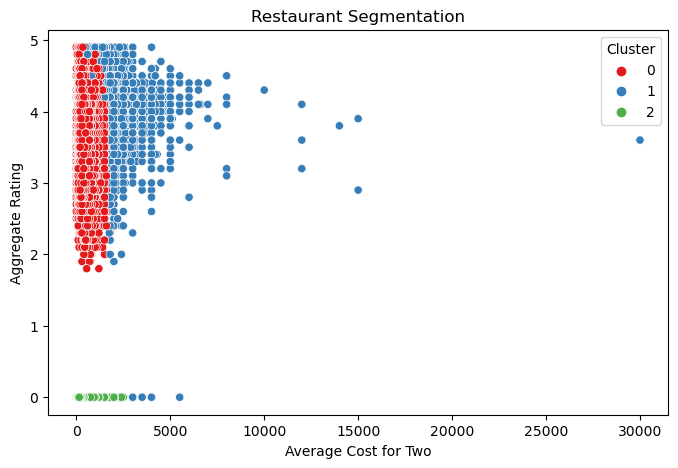

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='average_cost_for_two',
    y='aggregate_rating',
    hue='Cluster',
    palette='Set1'
)

plt.title('Restaurant Segmentation')
plt.xlabel('Average Cost for Two')
plt.ylabel('Aggregate Rating')

plt.show()

**The clustering analysis groups restaurants into distinct segments based on customer ratings, engagement levels, and pricing characteristics. These segments can support targeted business strategies and market positioning decisions.**

# Predictive Modeling

## Objective: 

**A machine learning model was developed to predict restaurant ratings based on operational and customer-related factors.**

In [32]:
# Data Preparation
from sklearn.model_selection import train_test_split

X = df[
    [
        'votes',
        'average_cost_for_two',
        'price_range'
    ]
]

y = df['aggregate_rating']

In [33]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
# Model Training
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
# Prediction
y_pred = model.predict(X_test)

In [36]:
# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.29051549655627884
RMSE: 0.4935124191383175
R2 Score: 0.8828306349153684


**The predictive model estimates restaurant ratings using customer engagement and pricing-related variables. Model performance metrics indicate the effectiveness of these factors in explaining rating variations.**

# Feature Importance Analysis

In [37]:
importance = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }
)

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,votes,0.985267
1,average_cost_for_two,0.011744
2,price_range,0.002989


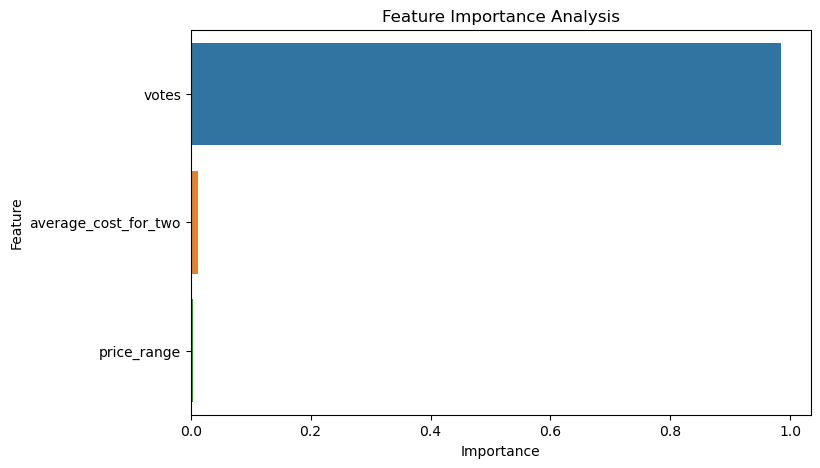

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance Analysis')

plt.show()

**Feature importance analysis identifies the variables that contribute most significantly to rating predictions. These factors represent key business drivers influencing restaurant performance and customer satisfaction.**

## Model Performance Summary

The predictive model demonstrated the ability to estimate restaurant ratings using operational and customer-related variables. Feature importance analysis revealed that customer engagement and pricing factors contribute significantly to rating prediction. These findings validate the role of business and customer behavior metrics in determining restaurant success.

# Key Findings

1. Restaurant performance varies significantly across cities, indicating the influence of local market dynamics and customer preferences.

2. Popular cuisine categories dominate restaurant offerings, reflecting strong customer demand within specific food segments.

3. Highly rated cuisines are not always the most common, suggesting that quality and customer experience can outweigh market popularity.

4. The majority of restaurants operate within mid-range pricing segments, highlighting the importance of affordability in attracting customers.

5. Online delivery services are associated with improved customer convenience and may contribute positively to customer ratings.

6. Customer engagement, measured through votes, exhibits a positive relationship with restaurant ratings, indicating the importance of visibility and customer trust.

7. Restaurant segmentation identified distinct business groups characterized by differences in pricing, engagement, and customer satisfaction levels.

8. Predictive modeling confirmed that operational and customer-related variables can effectively explain variations in restaurant ratings.

# Business Recommendations

1. Expand online delivery capabilities to improve customer accessibility and convenience.

2. Monitor customer feedback and engagement metrics regularly to strengthen brand reputation and customer loyalty.

3. Adopt pricing strategies that balance affordability with perceived value.

4. Analyze high-performing cuisine categories to identify growth opportunities and changing customer preferences.

5. Develop targeted business strategies for different restaurant segments identified through clustering analysis.

6. Use predictive analytics to support operational decision-making and performance monitoring.

# Business Impact

The insights generated from this analysis can help restaurant owners optimize pricing strategies, improve customer engagement, enhance service offerings, and identify high-performing market segments. The predictive modeling framework can also support data-driven decision-making for performance improvement and business expansion.

# Conclusion

This project analyzed restaurant performance using exploratory data analysis, segmentation techniques, and predictive modeling. The findings indicate that restaurant success is influenced by a combination of customer engagement, service offerings, pricing strategies, and market positioning. Online delivery services and customer interaction metrics emerged as important contributors to customer satisfaction. The predictive model further demonstrated that restaurant ratings can be effectively estimated using operational and business-related features. These insights can support restaurant owners and stakeholders in making data-driven decisions to enhance customer experience and business performance.

# Future Scope

1. Incorporate temporal data to analyze seasonal and yearly trends in restaurant performance.

2. Integrate customer review text and perform sentiment analysis to better understand customer opinions.

3. Develop advanced machine learning models to improve rating prediction accuracy.

4. Build interactive dashboards using Power BI or Tableau for real-time business monitoring.

5. Analyze geographic patterns using geospatial analytics to identify high-potential restaurant locations.

6. Expand segmentation analysis using additional customer and operational variables.

In [39]:
df.to_csv("zomato_cleaned.csv", index=False)

In [41]:
df.to_excel("zomato_cleaned.xlsx", index=False)

In [42]:
import os 
os.getcwd()

'C:\\Users\\SAMSUNG'